<a href="https://colab.research.google.com/github/abdullaawad/Breast-Cancer-Mortality-Prediction/blob/main/Breast%20cancer%20mortality%20status%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Breast Cancer Mortality status prediction & Survival Period estimation Project**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv('/content/Breast Cancer Data.csv')

## **Section A: Data Wrangling, Cleaning, & Pre-Processing**

In [ ]:
df.head()

,Patient_ID,Month_of_Birth,Age,Sex,Occupation,T_Stage,N_Stage,6th_Stage,Differentiated,Grade,A_Stage,Tumor_Size,Estrogen_Status,Progesterone_Status,Regional_Node_Examined,Reginol_Node_Positive,Survival_Months,Mortality_Status
0,A0012,12,68.0,Female,Teaching,T1,N1,IIA,Poorly differentiated,3,Regional,4.0,Positive,Positive,24.0,1,60,Alive
1,A0013,12,50.0,Female,Medical,T2,N2,IIIA,Moderately differentiated,2,Regional,35.0,Positive,Positive,14.0,5,62,Alive
2,A0014,11,58.0,Female,Engineering,T3,N3,IIIC,Moderately differentiated,2,Regional,63.0,Positive,Positive,14.0,7,75,Alive
3,A0015,3,58.0,Female,Technology,T1,N1,IIA,Poorly differentiated,3,Regional,18.0,Positive,Positive,2.0,1,84,Alive
4,A0016,1,47.0,Female,Multimedia,T2,N1,IIB,Poorly differentiated,3,Regional,41.0,Positive,Positive,3.0,1,50,Alive


In [ ]:
df.shape

(4024, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient_ID              4024 non-null   object 
 1   Month_of_Birth          4024 non-null   int64  
 2   Age                     4015 non-null   float64
 3   Sex                     4020 non-null   object 
 4   Occupation              43 non-null     object 
 5   T_Stage                 4024 non-null   object 
 6   N_Stage                 4024 non-null   object 
 7   6th_Stage               4024 non-null   object 
 8   Differentiated          4024 non-null   object 
 9   Grade                   4024 non-null   int64  
 10  A_Stage                 4024 non-null   object 
 11  Tumor_Size              4021 non-null   float64
 12  Estrogen_Status         4024 non-null   object 
 13  Progesterone_Status     4024 non-null   object 
 14  Regional_Node_Examined  4023 non-null   

In [ ]:
df_gender = df['Sex'] == 'Female'
df_gender.value_counts()

,count
Sex,
True,4001
False,23


In [ ]:
df['Sex'].unique()

array(['Female', '1', nan], dtype=object)

In [ ]:
df_gender.value_counts()

,count
Sex,
True,4001
False,23


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
Patient_ID,0
Month_of_Birth,0
Age,9
Sex,4
Occupation,3981
T_Stage,0
N_Stage,0
6th_Stage,0
Differentiated,0
Grade,0


In [ ]:
df = df.drop(['Patient_ID', 'Month_of_Birth', 'Occupation', 'Sex'], axis=1)
df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4011 entries, 0 to 4023
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4011 non-null   float64
 1   T_Stage                 4011 non-null   object 
 2   N_Stage                 4011 non-null   object 
 3   6th_Stage               4011 non-null   object 
 4   Differentiated          4011 non-null   object 
 5   Grade                   4011 non-null   int64  
 6   A_Stage                 4011 non-null   object 
 7   Tumor_Size              4011 non-null   float64
 8   Estrogen_Status         4011 non-null   object 
 9   Progesterone_Status     4011 non-null   object 
 10  Regional_Node_Examined  4011 non-null   float64
 11  Reginol_Node_Positive   4011 non-null   int64  
 12  Survival_Months         4011 non-null   int64  
 13  Mortality_Status        4011 non-null   object 
dtypes: float64(3), int64(3), object(8)
memory usa

In [ ]:
df.isnull().sum()

,0
Age,0
T_Stage,0
N_Stage,0
6th_Stage,0
Differentiated,0
Grade,0
A_Stage,0
Tumor_Size,0
Estrogen_Status,0
Progesterone_Status,0


In [ ]:
df.shape

(4011, 14)

In [ ]:
df['A_Stage'].unique()

array(['Regional', 'Distant'], dtype=object)

In [ ]:
df['Differentiated'].unique()

array(['Poorly differentiated', 'Moderately differentiated',
       'Well differentiated', 'Undifferentiated'], dtype=object)

In [ ]:
df['6th_Stage'].unique()

array(['IIA', 'IIIA', 'IIIC', 'IIB', 'IIIB'], dtype=object)

In [ ]:
e = df['Estrogen_Status'].unique()
p = df['Progesterone_Status'].unique()
m = df['Mortality_Status'].unique()
print(e)
print(p)
print(m)

['Positive' 'Negative']
['Positive' 'Negative']
['Alive' 'Dead' 'ALIVE' 'DEAD' 'ALive' 'alive' 'dead']


In [ ]:
df = df.rename(columns={'Reginol_Node_Positive': 'Regional_Node_Positive'})

In [ ]:
df['Mortality_Status'] = df['Mortality_Status'].replace('ALIVE', 'Alive')
df['Mortality_Status'] = df['Mortality_Status'].replace('DEAD', 'Dead')
df['Mortality_Status'] = df['Mortality_Status'].replace('alive', 'Alive')
df['Mortality_Status'] = df['Mortality_Status'].replace('ALive', 'Alive')
df['Mortality_Status'] = df['Mortality_Status'].replace('dead', 'Dead')

In [ ]:
df.head()

,Age,T_Stage,N_Stage,6th_Stage,Differentiated,Grade,A_Stage,Tumor_Size,Estrogen_Status,Progesterone_Status,Regional_Node_Examined,Regional_Node_Positive,Survival_Months,Mortality_Status
0,68.0,T1,N1,IIA,Poorly differentiated,3,Regional,4.0,Positive,Positive,24.0,1,60,Alive
1,50.0,T2,N2,IIIA,Moderately differentiated,2,Regional,35.0,Positive,Positive,14.0,5,62,Alive
2,58.0,T3,N3,IIIC,Moderately differentiated,2,Regional,63.0,Positive,Positive,14.0,7,75,Alive
3,58.0,T1,N1,IIA,Poorly differentiated,3,Regional,18.0,Positive,Positive,2.0,1,84,Alive
4,47.0,T2,N1,IIB,Poorly differentiated,3,Regional,41.0,Positive,Positive,3.0,1,50,Alive


In [ ]:
df['Grade'].value_counts()

,count
Grade,
2,2344
3,1108
1,540
4,19


# **Label Encoding Data:**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
df['T_Stage'] = le.fit_transform(df['T_Stage'])
df['N_Stage'] = le.fit_transform(df['N_Stage'])
df['6th_Stage'] = le.fit_transform(df['6th_Stage'])
df['Differentiated'] = le.fit_transform(df['Differentiated'])
df['A_Stage'] = le.fit_transform(df['A_Stage'])
df['Estrogen_Status'] = le.fit_transform(df['Estrogen_Status'])
df['Progesterone_Status'] = le.fit_transform(df['Progesterone_Status'])
df['Mortality_Status'] = le.fit_transform(df['Mortality_Status'])

In [ ]:
df.head()

,Age,T_Stage,N_Stage,6th_Stage,Differentiated,Grade,A_Stage,Tumor_Size,Estrogen_Status,Progesterone_Status,Regional_Node_Examined,Regional_Node_Positive,Survival_Months,Mortality_Status
0,68.0,0,0,0,1,3,1,4.0,1,1,24.0,1,60,0
1,50.0,1,1,2,0,2,1,35.0,1,1,14.0,5,62,0
2,58.0,2,2,4,0,2,1,63.0,1,1,14.0,7,75,0
3,58.0,0,0,0,1,3,1,18.0,1,1,2.0,1,84,0
4,47.0,1,0,1,1,3,1,41.0,1,1,3.0,1,50,0


# **Outlier Detection:**

In [ ]:
import plotly.express as px

In [ ]:
age_ol = px.box(df, x='Age')
age_ol.show()

In [ ]:
df.drop(df[df['Age'] > 88].index, inplace=True)

In [ ]:
df.drop(df[df['Age'] < 0].index, inplace=True)

In [ ]:
tumor_size_ol = px.box(df, x='Tumor_Size')
tumor_size_ol.show()

In [ ]:
df.drop(df[df['Tumor_Size'] < 0].index, inplace=True)

In [ ]:
regnode_ol = px.box(df, x='Regional_Node_Examined')
regnode_ol.show()

In [ ]:
regnode_pos = px.box(df, x='Regional_Node_Positive')
regnode_pos.show()

# **Standardising Data:**

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_cols = df.drop(['Survival_Months', 'Mortality_Status'], axis=1).columns

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [ ]:
df.head()

,Age,T_Stage,N_Stage,6th_Stage,Differentiated,Grade,A_Stage,Tumor_Size,Estrogen_Status,Progesterone_Status,Regional_Node_Examined,Regional_Node_Positive,Survival_Months,Mortality_Status
0,1.563375,-1.024935,-0.631785,-1.042581,0.306535,1.329876,0.1516,-1.259462,0.268296,0.458155,1.183821,-0.618246,60,0
1,-0.445174,0.283507,0.811162,0.537063,-0.679001,-0.237953,0.1516,0.220339,0.268296,0.458155,-0.045637,0.166511,62,0
2,0.447514,1.591948,2.254109,2.116708,-0.679001,-0.237953,0.1516,1.556933,0.268296,0.458155,-0.045637,0.558890,75,0
3,0.447514,-1.024935,-0.631785,-1.042581,0.306535,1.329876,0.1516,-0.591165,0.268296,0.458155,-1.520986,-0.618246,84,0
4,-0.779933,0.283507,-0.631785,-0.252759,0.306535,1.329876,0.1516,0.506752,0.268296,0.458155,-1.398040,-0.618246,50,0


# **Model Implementation:**

### **1. Logistic Regression:**

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

In [ ]:
X = df.drop(['Survival_Months', 'Mortality_Status'], axis=1)
y = df['Mortality_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

y_pred_lr

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,

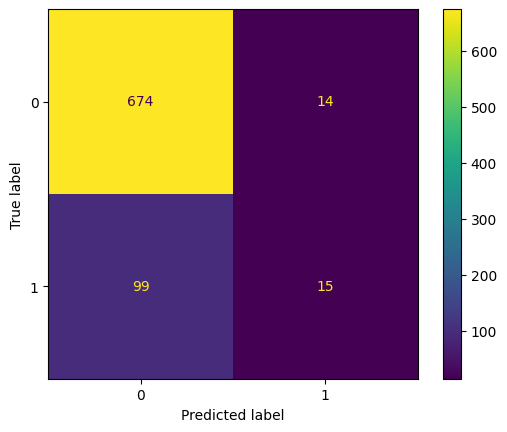

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lr_disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=model_lr.classes_)
cm_lr_disp.plot()

In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92       688
           1       0.52      0.13      0.21       114

    accuracy                           0.86       802
   macro avg       0.69      0.56      0.57       802
weighted avg       0.82      0.86      0.82       802



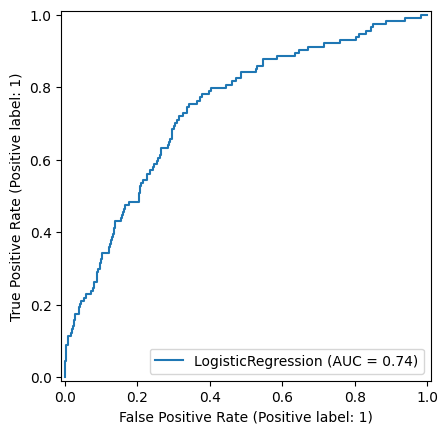

In [73]:
roc_lr = RocCurveDisplay.from_estimator(model_lr, X_test, y_test)

## **2. Naive Bayes:**

In [ ]:
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)

y_pred_nb

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0,

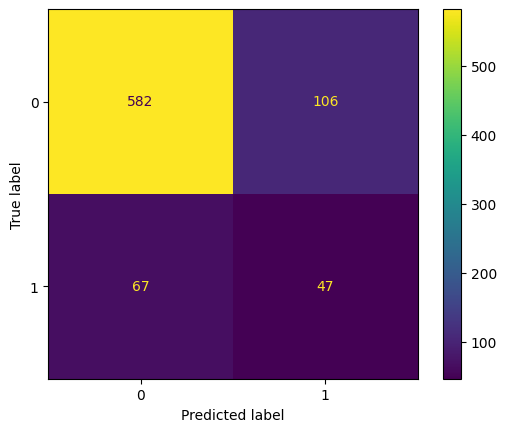

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_nb_disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=model_nb.classes_)
cm_nb_disp.plot()

In [ ]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.90      0.85      0.87       688
           1       0.31      0.41      0.35       114

    accuracy                           0.78       802
   macro avg       0.60      0.63      0.61       802
weighted avg       0.81      0.78      0.80       802



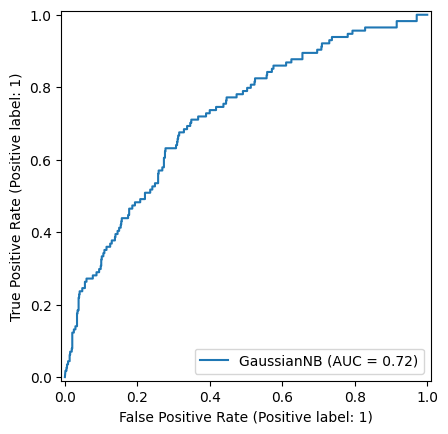

In [74]:
roc_nb = RocCurveDisplay.from_estimator(model_nb, X_test, y_test)

## **3. kNN:**

In [ ]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

y_pred_knn

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,

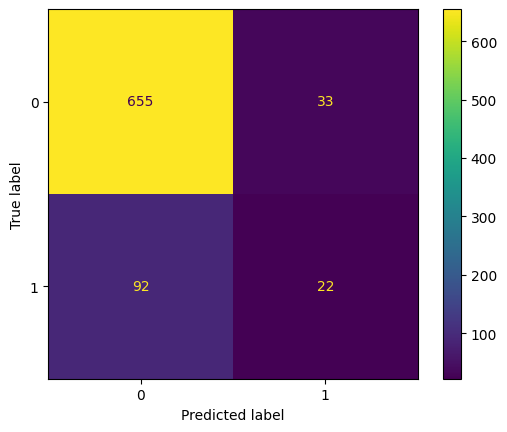

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_knn_disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=model_knn.classes_)
cm_knn_disp.plot()

In [ ]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91       688
           1       0.40      0.19      0.26       114

    accuracy                           0.84       802
   macro avg       0.64      0.57      0.59       802
weighted avg       0.81      0.84      0.82       802



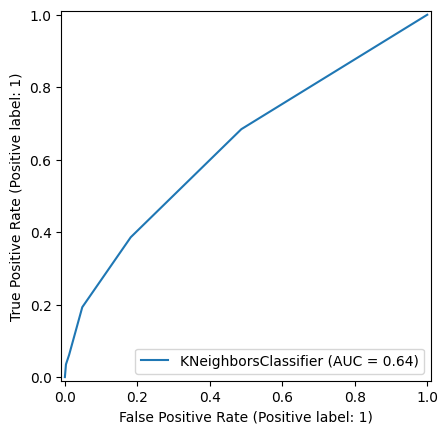

In [75]:
roc_knn = RocCurveDisplay.from_estimator(model_knn, X_test, y_test)

In [67]:
from sklearn.metrics import classification_report
import pandas as pd

def get_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    metrics = {
        'Model': model_name,
        'Accuracy': report['accuracy'],
        'Class 0 Precision': report['0']['precision'],
        'Class 0 Recall': report['0']['recall'],
        'Class 0 F1-Score': report['0']['f1-score'],
        'Class 1 Precision': report['1']['precision'],
        'Class 1 Recall': report['1']['recall'],
        'Class 1 F1-Score': report['1']['f1-score']
    }
    return metrics

metrics_lr = get_metrics(y_test, y_pred_lr, 'Logistic Regression')
metrics_nb = get_metrics(y_test, y_pred_nb, 'Naive Bayes')
metrics_knn = get_metrics(y_test, y_pred_knn, 'k-Nearest Neighbors')

summary_df = pd.DataFrame([metrics_lr, metrics_nb, metrics_knn])

# Display the table, rounding to 2 decimal places for better readability
print(summary_df.round(2).to_markdown(index=False))


| Model               |   Accuracy |   Class 0 Precision |   Class 0 Recall |   Class 0 F1-Score |   Class 1 Precision |   Class 1 Recall |   Class 1 F1-Score |
|:--------------------|-----------:|--------------------:|-----------------:|-------------------:|--------------------:|-----------------:|-------------------:|
| Logistic Regression |       0.86 |                0.87 |             0.98 |               0.92 |                0.52 |             0.13 |               0.21 |
| Naive Bayes         |       0.78 |                0.9  |             0.85 |               0.87 |                0.31 |             0.41 |               0.35 |
| k-Nearest Neighbors |       0.84 |                0.88 |             0.95 |               0.91 |                0.4  |             0.19 |               0.26 |


# **Next Tasks:**

## **To enhance your selected best model/s performance, tune some of its possible hyperparameters, which you indicated in Task (4.a) for that specific algorithm. With the aid of Python Notebook, Re-train and test the best algorithm again with GridSearchCV t**

## **With the aid of your Python Notebook, combine only TWO out of the THREE base learners (NB, LR, KNN) that you already built into a probability-based voting ensemble classifier.**